In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/churnguard_data.csv')

print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nShape:")
print(df.shape)

  customerID  gender  SeniorCitizen  tenure PhoneService InternetService  \
0  CUST-0032    Male              0    21.0          YES     Fiber optic   
1  CUST-0110    Male              0    55.0          YES     Fiber optic   
2  CUST-0137  Female              1    46.0          Yes     Fiber optic   
3  CUST-0089  Female              1    63.0          Yes     Fiber optic   
4  CUST-0919  Female              0     8.0          Yes             DSl   

         Contract PaperlessBilling     PaymentMethod  MonthlyCharges  \
0  Month-to-month               No     Credit card             29.73   
1        Two year              Yes     Bank transfer           46.32   
2  Month-to-month               No    Mailed check             87.06   
3  Month-to-month              YES      Mailed check           56.97   
4  month to month               No  Electronic check           39.69   

  TotalCharges Churn  
0       600.01   Yes  
1      2515.48    No  
2      4153.97   Yes  
3       3641.3   Y

In [28]:
null_count = df.isnull().sum()
null_percent = (df.isnull().sum() / df.shape[0])*100
null_report = pd.DataFrame({'Null Count': null_count, 'Null Percent': null_percent})
print(null_report)

                  Null Count  Null Percent
customerID                 0      0.000000
gender                     0      0.000000
SeniorCitizen              0      0.000000
tenure                    50      4.854369
PhoneService               0      0.000000
InternetService           16      1.553398
Contract                   0      0.000000
PaperlessBilling           0      0.000000
PaymentMethod              0      0.000000
MonthlyCharges            75      7.281553
TotalCharges              64      6.213592
Churn                      0      0.000000


In [29]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
df.drop_duplicates(inplace=True)
print("New shape after removing duplicates:",df.shape)

Duplicate rows: 30
New shape after removing duplicates: (1000, 12)


In [30]:
print("Before conversion:")
print(df['TotalCharges'].dtype)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\nAfter conversion:")
print(df['TotalCharges'].dtype)
print("\nMemory usage:")
print(df.memory_usage(deep=True).sum())


Before conversion:
object

After conversion:
float64

Memory usage:
484822


In [31]:
print(df.describe())
skew_values = df.select_dtypes(include=['int64', 'float64']).skew()
print("\nSkew values:")
print(skew_values)
highest_skew_column = skew_values.idxmax()
print("\nColumn with highest absolute skewness:", highest_skew_column)
print("Skewness value:",skew_values[highest_skew_column])

       SeniorCitizen      tenure  MonthlyCharges  TotalCharges
count     1000.00000  950.000000      930.000000    902.000000
mean         0.16300   35.720000       70.501538   2320.755288
std          0.36955   20.387333       81.627719   1704.433072
min          0.00000   -5.000000        0.010000     20.330000
25%          0.00000   18.000000       42.445000    938.920000
50%          0.00000   36.000000       64.720000   1897.930000
75%          0.00000   53.000000       88.947500   3388.832500
max          1.00000   71.000000     1500.000000   7453.920000

Skew values:
SeniorCitizen      1.827492
tenure            -0.016535
MonthlyCharges    12.120272
TotalCharges       0.873965
dtype: float64

Column with highest absolute skewness: MonthlyCharges
Skewness value: 12.120272073941928


In [32]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols[:2]:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bounds = Q1 - 1.5*IQR
  upper_bounds = Q3 + 1.5*IQR
  outliers = df[(df[col] < lower_bounds) | (df[col] > upper_bounds)]
  df = df[(df[col] >= lower_bounds) & (df[col] <= upper_bounds)]
  print(f"\nColumn:{col}")
  print("Q1:",Q1)
  print("Q3:",Q3)
  print("IQR:",IQR)
  print("Outliers count:",outliers.shape[0])


Column:SeniorCitizen
Q1: 0.0
Q3: 0.0
IQR: 0.0
Outliers count: 163

Column:tenure
Q1: 17.0
Q3: 53.0
IQR: 36.0
Outliers count: 0


import matplotlib.pyplot as plt
import seaborn as sns

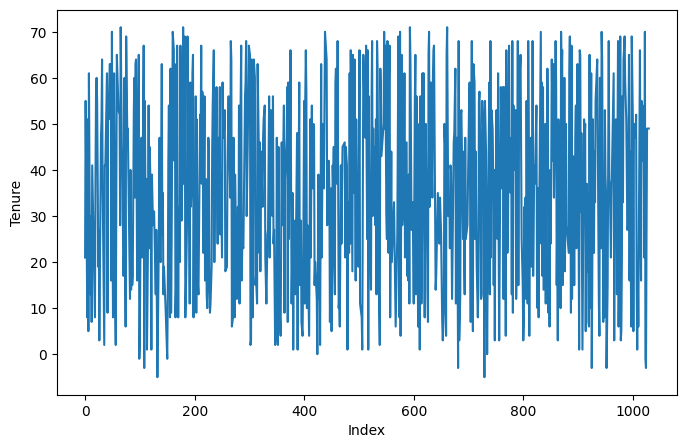

In [33]:
plt.figure(figsize=(8,5))
plt.plot(df['tenure'])
plt.xlabel('Index')
plt.ylabel('Tenure')
plt.show()

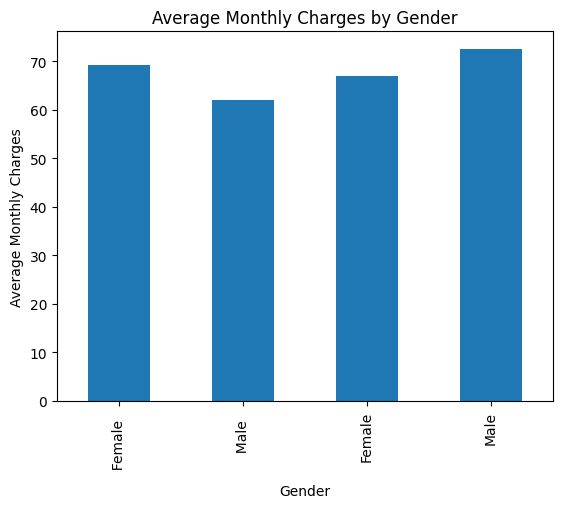

In [34]:
df.groupby('gender')['MonthlyCharges'].mean().plot(kind='bar')
plt.title('Average Monthly Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Monthly Charges')
plt.show()

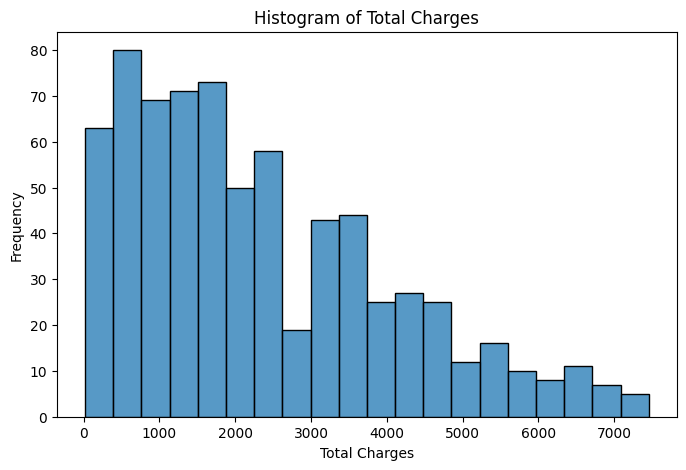

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalCharges'],bins=20)
plt.title("Histogram of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.show()

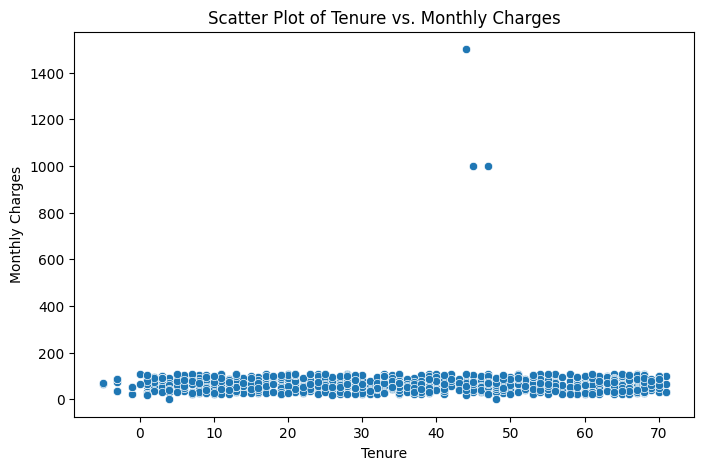

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['tenure'],y=df['MonthlyCharges'])
plt.title("Scatter Plot of Tenure vs. Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

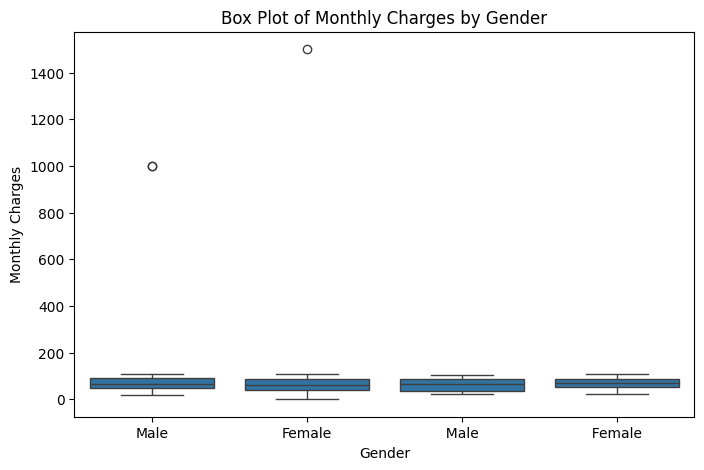

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['gender'],y=df['MonthlyCharges'])
plt.title("Box Plot of Monthly Charges by Gender")
plt.xlabel("Gender")
plt.ylabel("Monthly Charges")
plt.show()


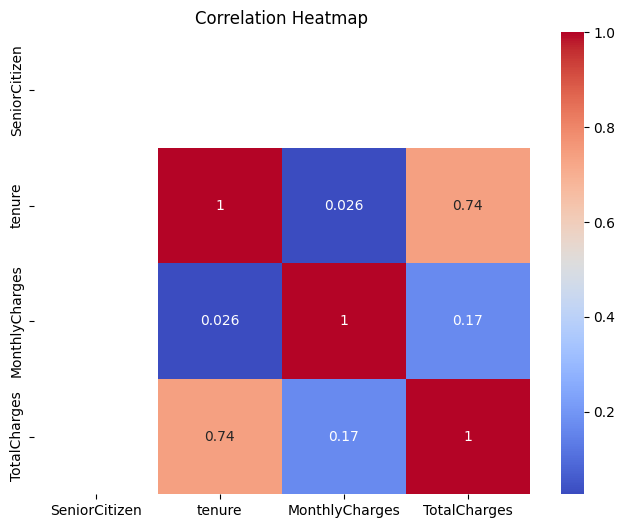

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen             NaN       NaN             NaN           NaN
tenure                    NaN  1.000000        0.025955      0.738538
MonthlyCharges            NaN  0.025955        1.000000      0.168813
TotalCharges              NaN  0.738538        0.168813      1.000000


In [38]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
print(corr_matrix)

In [39]:
skew_values = df.select_dtypes(include=['int64', 'float64']).skew()
top_2_skewed = skew_values.abs().sort_values(ascending=False).head(2).index
for col in top_2_skewed:
  print(f"\nColoumn:{col}")
  print("mean:",df[col].mean())
  print("median:",df[col].median())
  df[col].fillna(df[col].median(),inplace=True)
  print("\nRemaining null values:")
  print(df[top_2_skewed].isnull().sum())


Coloumn:MonthlyCharges
mean: 69.32870619946092
median: 64.33500000000001

Remaining null values:
MonthlyCharges     0
TotalCharges      77
dtype: int64

Coloumn:TotalCharges
mean: 2336.4364245810057
median: 1894.18

Remaining null values:
MonthlyCharges    0
TotalCharges      0
dtype: int64


/tmp/ipykernel_6357/268615036.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [40]:
pearson_corr=df.select_dtypes(include=['int64','float64']).corr(method='pearson')
spearman_corr=df.select_dtypes(include=['int64','float64']).corr(method='spearman')
print("Pearson Correlation:")
print(pearson_corr)
print("\nSpearman Correlation:")
print(spearman_corr)
difference = spearman_corr - pearson_corr
print("\nDifference:")
print(difference)


Pearson Correlation:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen             NaN       NaN             NaN           NaN
tenure                    NaN  1.000000        0.024783      0.695964
MonthlyCharges            NaN  0.024783        1.000000      0.162289
TotalCharges              NaN  0.695964        0.162289      1.000000

Spearman Correlation:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen             NaN       NaN             NaN           NaN
tenure                    NaN  1.000000       -0.002198      0.729126
MonthlyCharges            NaN -0.002198        1.000000      0.473126
TotalCharges              NaN  0.729126        0.473126      1.000000

Difference:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen             NaN       NaN             NaN           NaN
tenure                    NaN  0.000000       -0.026981      0.033162
MonthlyCharges            NaN -0.

In [41]:
grouped_report = df.groupby('gender')['MonthlyCharges'].agg(['mean','std','count'])
print(grouped_report)

                 mean        std  count
gender                                 
  Female    69.100476  25.349879     42
  Male      62.281071  26.529670     42
Female      66.686225  80.524665    355
Male        72.122458  74.462534    354


In [42]:
df.to_csv('Cleaned_data.csv',index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
